# Three-dataset PCA prediction figure

Minimal notebook for building the final 3 × 3 figure.

Layout:

- column 0: image panels **A**, **C**, **E**;
- columns 1–2: paired quantitative panels **B**, **D**, **F**;
- left quantitative panel: $\rho$ for PCs 1–2;
- right quantitative panel: $\epsilon$ for PCs 1–2.

The quantitative results are expected in the `real_gc_grid` subfolder of each dataset directory.

Panel letters are placed with fixed figure coordinates. If the layout changes, tune only the numbers in `ABSOLUTE_LABEL_POSITIONS`.


## 1. Imports and plotting style


In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.image import imread


In [2]:
mpl.rcParams.update(
    {
        "figure.dpi": 200,
        "savefig.dpi": 300,
        "font.size": 9,
        "axes.titlesize": 9,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.6,
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "figure.constrained_layout.use": True,
        "figure.constrained_layout.w_pad": 0.04,
        "figure.constrained_layout.h_pad": 0.04,
    }
)


## 2. Configuration


In [3]:
BASE = Path("cached_results")

COMPONENTS_1BASED = [1, 2]

DATASETS = [
    {
        "image_label": "A",
        "curve_label": "B",
        "name": "Gallego-Carracedo et al.",
        "dataset_dir": BASE / "1 Gallego-Carracedo et al",
        "image_file": "Subfig_A.png",
        "axis_name": "neurons",
    },
    {
        "image_label": "C",
        "curve_label": "D",
        "name": "Chillale et al.",
        "dataset_dir": BASE / "2 Chillale et al",
        "image_file": "Subfig_C.png",
        "axis_name": "trials",
    },
    {
        "image_label": "E",
        "curve_label": "F",
        "name": "Luo et al.",
        "dataset_dir": BASE / "3 Luo et al",
        "image_file": "Subfig_E.png",
        "axis_name": "animals",
    },
]

OUTPUT_DIR = BASE / "final_figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PNG = OUTPUT_DIR / "fig4.png"
OUTPUT_PDF = OUTPUT_DIR / "fig4.pdf"


## 3. Loading helpers


In [4]:
AXIS_SPECS = {
    "neurons": {
        "grid_file": "neurons_grid.npy",
        "prefix": "neurons",
        "xlabel": "Number of neurons",
    },
    "trials": {
        "grid_file": "trials_grid.npy",
        "prefix": "trials",
        "xlabel": "Number of trials",
    },
    "animals": {
        "grid_file": "D_grid.npy",
        "prefix": "animals",
        "xlabel": "Number of animals",
    },
}


def load_npy(path: Path) -> np.ndarray:
    """Load a required .npy file with a clear error message."""
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}")
    return np.load(path, allow_pickle=True)


def as_series_component_array(a: np.ndarray, name: str) -> np.ndarray:
    """
    Normalize rho/epsilon arrays to shape (S, L, K).

    Accepted input shapes:
    - (L, K): single-series format;
    - (S, L, K): three-series format.
    """
    a = np.asarray(a)

    if a.ndim == 2:
        return a[None, :, :]
    if a.ndim == 3:
        return a

    raise ValueError(f"{name} should have shape (L, K) or (S, L, K), got {a.shape}.")


def load_axis_results(dataset_cfg: dict) -> dict:
    """Load the grid, predictions, and empirical estimates for one dataset."""
    axis_name = dataset_cfg["axis_name"]
    spec = AXIS_SPECS[axis_name]
    prefix = spec["prefix"]

    results_dir = dataset_cfg["dataset_dir"] / "real_gc_grid"
    image_path = dataset_cfg["dataset_dir"] / dataset_cfg["image_file"]

    grid = load_npy(results_dir / spec["grid_file"])

    pred_rho = as_series_component_array(
        load_npy(results_dir / f"pred_{prefix}_mean_rho.npy"),
        f"pred_{prefix}_mean_rho",
    )
    pred_rho_std = as_series_component_array(
        load_npy(results_dir / f"pred_{prefix}_mean_rho_std.npy"),
        f"pred_{prefix}_mean_rho_std",
    )
    pred_eps = as_series_component_array(
        load_npy(results_dir / f"pred_{prefix}_epsilon.npy"),
        f"pred_{prefix}_epsilon",
    )
    pred_eps_std = as_series_component_array(
        load_npy(results_dir / f"pred_{prefix}_epsilon_std.npy"),
        f"pred_{prefix}_epsilon_std",
    )

    emp_rho = as_series_component_array(
        load_npy(results_dir / f"emp_{prefix}_mean_rho_mean.npy"),
        f"emp_{prefix}_mean_rho_mean",
    )
    emp_rho_std = as_series_component_array(
        load_npy(results_dir / f"emp_{prefix}_mean_rho_std.npy"),
        f"emp_{prefix}_mean_rho_std",
    )
    emp_eps = as_series_component_array(
        load_npy(results_dir / f"emp_{prefix}_epsilon_mean.npy"),
        f"emp_{prefix}_epsilon_mean",
    )
    emp_eps_std = as_series_component_array(
        load_npy(results_dir / f"emp_{prefix}_epsilon_std.npy"),
        f"emp_{prefix}_epsilon_std",
    )

    return {
        "axis_name": axis_name,
        "xlabel": spec["xlabel"],
        "results_dir": results_dir,
        "image_path": image_path,
        "grid": np.asarray(grid),
        "pred_rho": pred_rho,
        "pred_rho_std": pred_rho_std,
        "pred_eps": pred_eps,
        "pred_eps_std": pred_eps_std,
        "emp_rho": emp_rho,
        "emp_rho_std": emp_rho_std,
        "emp_eps": emp_eps,
        "emp_eps_std": emp_eps_std,
    }


## 4. Plotting helpers


In [5]:
def component_indices(components_1based: list[int], K: int) -> list[int]:
    """Convert 1-based component labels to 0-based Python indices."""
    idx = []
    for comp in components_1based:
        if comp < 1 or comp > K:
            raise ValueError(f"Component {comp} is out of bounds. Available range: 1..{K}.")
        idx.append(comp - 1)
    return idx


def plot_image_panel(ax, image_path: Path) -> None:
    """Show one image panel without distorting its aspect ratio."""
    if not image_path.exists():
        raise FileNotFoundError(f"Missing image file: {image_path}")

    ax.imshow(imread(image_path))
    ax.set_axis_off()
    ax.set_anchor("N")


def plot_metric_panel(
    ax,
    x: np.ndarray,
    pred: np.ndarray,
    pred_std: np.ndarray,
    emp: np.ndarray,
    emp_std: np.ndarray,
    metric_label: str,
    xlabel: str,
    components_1based: list[int],
) -> None:
    """
    Plot prediction bands and empirical error bars for selected components.

    Input arrays must have shape (S, L, K), where:
    - S is the number of base-series fits;
    - L is the number of target dataset sizes;
    - K is the number of components.
    """
    K = 2
    comp_idx = component_indices(components_1based, K)
    colors = [plt.cm.hsv(i / max(1, K)) for i in range(K)]

    S_pred = pred.shape[0]
    S_emp = emp.shape[0]
    S_draw = max(S_pred, S_emp)

    for k in comp_idx:
        base_color = np.array(colors[k][:3])

        for s in range(S_pred):
            shade = 0.35 + 0.65 * (s + 1) / max(1, S_draw)
            color = shade * base_color

            y = pred[s, :, k]
            yerr = pred_std[s, :, k]

            ax.fill_between(x, y - yerr, y + yerr, color=color, alpha=0.25, linewidth=0)

        for s in range(S_emp):
            shade = 0.35 + 0.55 * (s + 1) / max(1, S_draw)
            color = shade * base_color

            ax.errorbar(
                x,
                emp[s, :, k],
                emp_std[s, :, k],
                linestyle="",
                marker="o",
                markersize=3,
                capsize=2,
                color=color,
                alpha=0.95,
                label=fr"PC {k + 1}" if s == 0 else None,
            )

    ax.set_xlabel(xlabel,fontsize=14)
    ax.set_ylabel(metric_label,fontsize=14)
    ax.set_ylim(bottom=0)
    ax.tick_params(length=3)
    ax.legend(frameon=False, loc="best")


ABSOLUTE_LABEL_POSITIONS = {
    # x, y in figure coordinates. Tune these six pairs manually if needed.
    "A": (0.005, 0.985),
    "D": (0.270, 0.985),
    "B": (0.005, 0.660),
    "E": (0.270, 0.660),
    "C": (0.005, 0.345),
    "F": (0.270, 0.345),
}


def add_panel_labels_absolute(
    fig: plt.Figure,
    positions: dict[str, tuple[float, float]] = ABSOLUTE_LABEL_POSITIONS,
    *,
    fontsize: int = 18,
) -> None:
    """
    Add A--F labels using fixed figure coordinates.

    Coordinates are absolute in figure space:
    - x=0 is the left edge of the figure;
    - x=1 is the right edge of the figure;
    - y=0 is the bottom edge;
    - y=1 is the top edge.

    This is intentionally manual. For a fixed publication layout it is more
    predictable than deriving label positions from axes whose visible extents
    change because of image aspect ratios, titles, legends, and axis labels.
    """
    for label, (x, y) in positions.items():
        fig.text(x,y,label,transform=fig.transFigure, fontsize=fontsize, fontweight="bold", ha="left", va="top",)


## 5. Build the full figure


In [6]:
def make_figure(datasets: list[dict], components_1based: list[int]) -> plt.Figure:
    """
    Build the 3-row by 3-column figure.

    Column 0 contains images.
    Columns 1 and 2 contain rho and epsilon panels for the same dataset row.
    """
    fig, ax = plt.subplots(
        nrows=3,
        ncols=3,
        figsize=(11.5, 9.0),
        constrained_layout=True,
        gridspec_kw={"width_ratios": [1.00, 1.15, 1.15]},
    )

    for row, cfg in enumerate(datasets):
        results = load_axis_results(cfg)

        plot_image_panel(ax[row, 0], results["image_path"])

        plot_metric_panel(
            ax[row, 1],
            x=results["grid"],
            pred=results["pred_rho"],
            pred_std=results["pred_rho_std"],
            emp=results["emp_rho"],
            emp_std=results["emp_rho_std"],
            metric_label=r"$\rho$",
            xlabel=results["xlabel"],
            components_1based=components_1based,
        )

        plot_metric_panel(
            ax[row, 2],
            x=results["grid"],
            pred=results["pred_eps"],
            pred_std=results["pred_eps_std"],
            emp=results["emp_eps"],
            emp_std=results["emp_eps_std"],
            metric_label=r"$\epsilon$",
            xlabel=results["xlabel"],
            components_1based=components_1based,
        )

        #ax[row, 1].set_title(r"$\rho$",fontsize=14)
        #ax[row, 2].set_title(r"$\epsilon$",fontsize=14)

        print(
            f"{cfg['curve_label']}: loaded {cfg['name']} "
            f"from {results['results_dir']} "
            f"using axis_name='{results['axis_name']}'"
        )

    add_panel_labels_absolute(fig)
    return fig


## 6. Run and save


B: loaded Gallego-Carracedo et al. from cached_results/1 Gallego-Carracedo et al/real_gc_grid using axis_name='neurons'
D: loaded Chillale et al. from cached_results/2 Chillale et al/real_gc_grid using axis_name='trials'
F: loaded Luo et al. from cached_results/3 Luo et al/real_gc_grid using axis_name='animals'
Saved PNG: cached_results/final_figures/fig4.png
Saved PDF: cached_results/final_figures/fig4.pdf


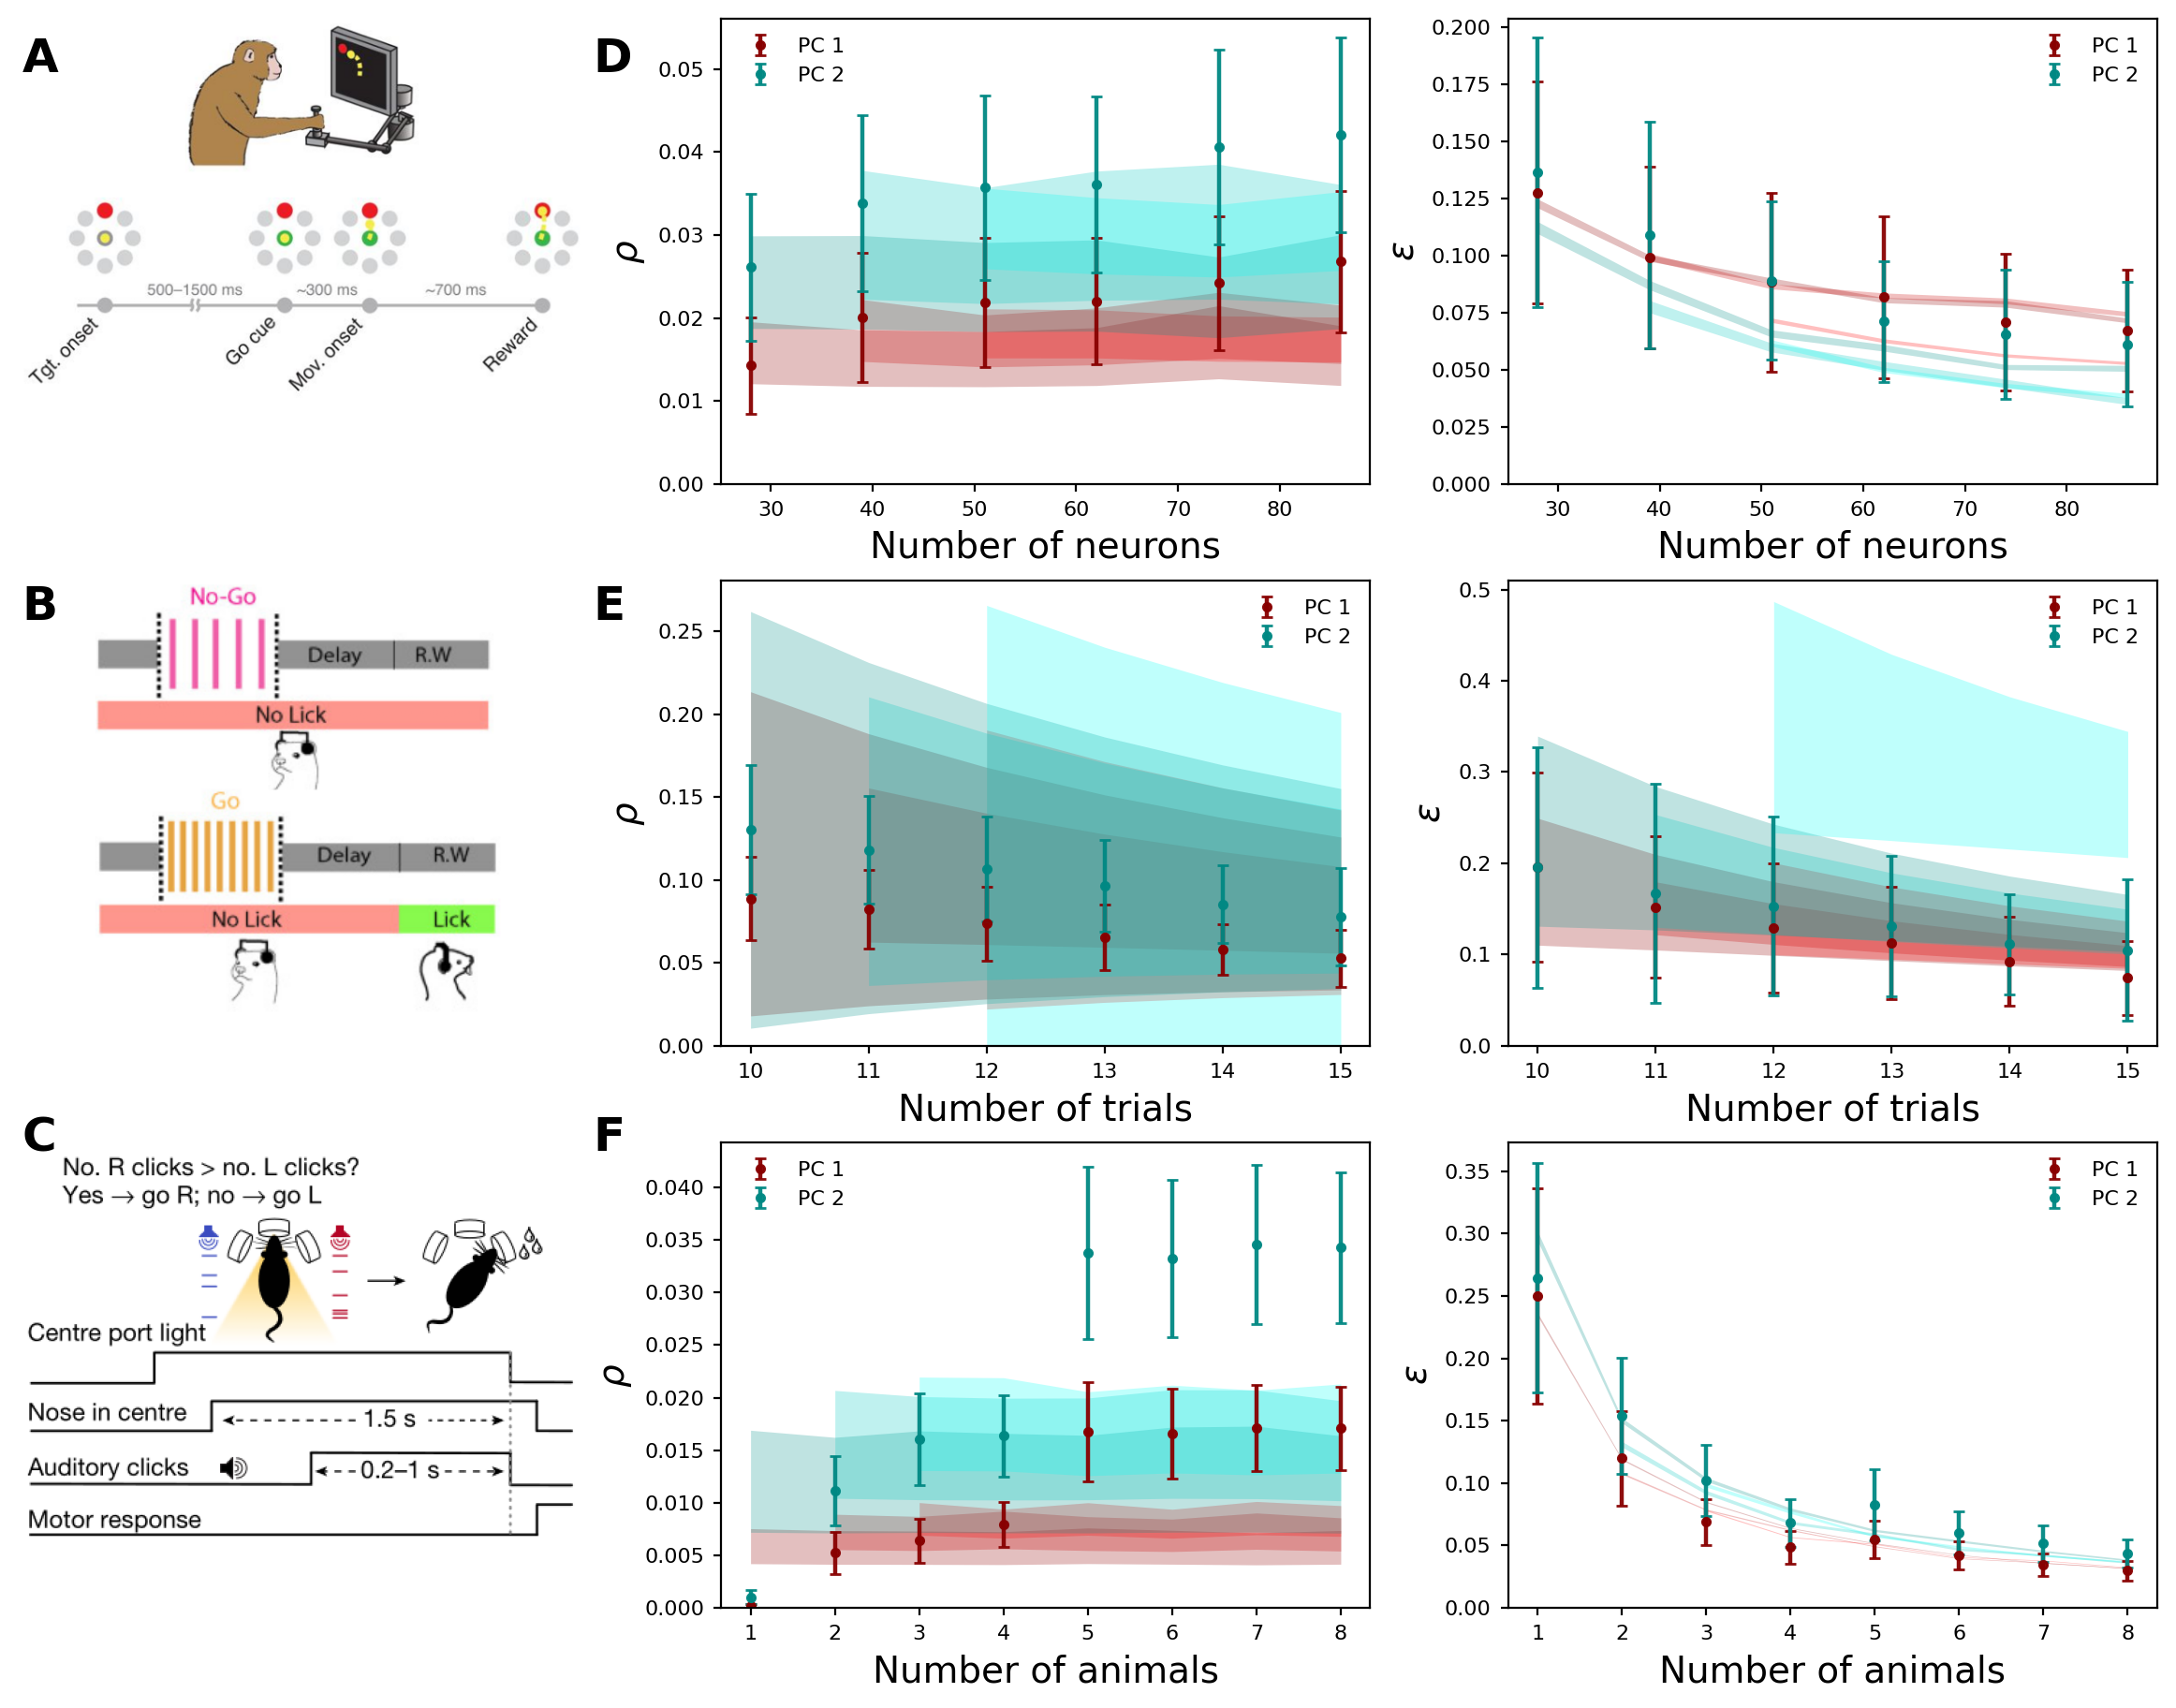

In [7]:
fig = make_figure(DATASETS, components_1based=COMPONENTS_1BASED)

fig.savefig(OUTPUT_PNG, bbox_inches="tight")
fig.savefig(OUTPUT_PDF, bbox_inches="tight")

print(f"Saved PNG: {OUTPUT_PNG}")
print(f"Saved PDF: {OUTPUT_PDF}")

plt.show()


## Optional

Load the Potentials for the inference done on the largest size (here N=50 neurons for the first dataset, n_trials=12 for the second dataset and n_animals=3 for the third dataset), and calculate the beginning of the asymptotic regime for both components using simple approximation, where noise strength is the same for all neurons, there are no temporal correlations for the noise, and no trial-to-trial variability.

In [8]:
# Asymptotic-onset estimates from the saved initial-fit Potentials.
#
# This follows the storage convention used by SVD_run_the_inference.py:
#
#   cached_results/<dataset>/real_gc_grid/
#       pots_initial_fit_three_series/<axis>_axis/base_<axis>_<base>/pot_pc<k>.npz
#
# Important: the inference script saves the *initial fitted* Potentials for the
# three base sizes, not the extrapolated Potentials at every target grid point.
# By default, this cell uses the largest available saved base for each axis.

import contextlib
import io

from pcalib.classes import Potential
from pcalib.functions import (
    asymptotic_regime_animals,
    asymptotic_regime_neurons,
    asymptotic_regime_trials,
)

ASYMPTOTIC_COMPONENTS_1BASED = [1, 2]
VERBOSE_ASYMPTOTICS = False

# Choose how to select the saved initial-fit Potentials.
# - "largest_saved_base": use max(base_<axis>_series.npy), consistent with what was actually saved.
# - "manual": use MANUAL_BASE_VALUES below.
ASYMPTOTIC_BASE_MODE = "largest_saved_base"

# Only used if ASYMPTOTIC_BASE_MODE = "manual".
# These must correspond to saved folders such as base_neurons_50, base_trials_12, base_animals_3.
MANUAL_BASE_VALUES = {
    "neurons": 50,
    "trials": 12,
    "animals": 3,
}

ASYMPTOTIC_FUNCTIONS = {
    "neurons": asymptotic_regime_neurons,
    "trials": asymptotic_regime_trials,
    "animals": asymptotic_regime_animals,
}

# Tolerances and n_trials passed to the analytical asymptotic functions.
# For the trials axis, n_trials should be the number of trials used in the saved base fit.
ASYMPTOTIC_KWARGS = {
    "neurons": dict(n_trials=1, delta_rho=0.01, delta_epsilon=0.01),
    "trials": dict(n_trials=None, delta_rho=0.05, delta_epsilon=0.05),
    "animals": dict(n_trials=1, delta_rho=0.05, delta_epsilon=0.05),
}


def results_dir(dataset_cfg: dict) -> Path:
    return Path(dataset_cfg["dataset_dir"]) / "real_gc_grid"


def base_series_file(axis_name: str) -> str:
    return f"base_{axis_name}_series.npy"


def load_base_series(dataset_cfg: dict, axis_name: str) -> np.ndarray:
    path = results_dir(dataset_cfg) / base_series_file(axis_name)
    if not path.exists():
        raise FileNotFoundError(f"Missing base-series file: {path}")
    return np.load(path).astype(int)


def choose_base_value(dataset_cfg: dict, axis_name: str) -> int:
    if ASYMPTOTIC_BASE_MODE == "manual":
        return int(MANUAL_BASE_VALUES[axis_name])
    if ASYMPTOTIC_BASE_MODE == "largest_saved_base":
        return int(np.max(load_base_series(dataset_cfg, axis_name)))
    raise ValueError(f"Unknown ASYMPTOTIC_BASE_MODE={ASYMPTOTIC_BASE_MODE!r}")


def potential_path(dataset_cfg: dict, axis_name: str, base_value: int, pc_1based: int) -> Path:
    return (
        results_dir(dataset_cfg)
        / "pots_initial_fit_three_series"
        / f"{axis_name}_axis"
        / f"base_{axis_name}_{int(base_value)}"
        / f"pot_pc{int(pc_1based)}.npz"
    )


def load_saved_potential(dataset_cfg: dict, axis_name: str, base_value: int, pc_1based: int):
    path = potential_path(dataset_cfg, axis_name, base_value, pc_1based)
    if not path.exists():
        raise FileNotFoundError(
            f"Missing saved Potential: {path}\n"
            "Check ASYMPTOTIC_BASE_MODE / MANUAL_BASE_VALUES, or rerun the inference script."
        )
    return Potential.from_npz(str(path)), path


def as_scalar(x) -> float:
    return float(np.ravel(x)[0])


def print_asymptotics(results: list[dict]) -> None:
    """Small readable table, without pandas."""
    columns = [
        ("dataset", "dataset"),
        ("axis", "axis"),
        ("saved_base", "base"),
        ("PC", "PC"),
        ("rho_asymptotic_onset", "rho onset"),
        ("epsilon_asymptotic_onset", "epsilon onset"),
        ("rho_onset_ceiled", "ceil rho"),
        ("epsilon_onset_ceiled", "ceil eps"),
    ]

    table = []
    for row in results:
        table.append(
            {
                "dataset": row["dataset"],
                "axis": row["axis"],
                "saved_base": row["saved_base"],
                "PC": row["PC"],
                "rho_asymptotic_onset": f"{row['rho_asymptotic_onset']:.3g}",
                "epsilon_asymptotic_onset": f"{row['epsilon_asymptotic_onset']:.3g}",
                "rho_onset_ceiled": row["rho_onset_ceiled"],
                "epsilon_onset_ceiled": row["epsilon_onset_ceiled"],
            }
        )

    widths = {
        key: max(len(label), *(len(str(row[key])) for row in table))
        for key, label in columns
    }

    header = " | ".join(label.ljust(widths[key]) for key, label in columns)
    sep = "-+-".join("-" * widths[key] for key, _ in columns)
    print(header)
    print(sep)
    for row in table:
        print(" | ".join(str(row[key]).ljust(widths[key]) for key, _ in columns))


asymptotics = []

for dataset_cfg in DATASETS:
    axis_name = dataset_cfg["axis_name"]
    base_value = choose_base_value(dataset_cfg, axis_name)
    fn = ASYMPTOTIC_FUNCTIONS[axis_name]

    kwargs = dict(ASYMPTOTIC_KWARGS[axis_name])
    if kwargs.get("n_trials") is None:
        kwargs["n_trials"] = int(base_value)

    for pc in ASYMPTOTIC_COMPONENTS_1BASED:
        pot, path = load_saved_potential(dataset_cfg, axis_name, base_value, pc)

        if VERBOSE_ASYMPTOTICS:
            rho_onset, eps_onset = fn(pot, **kwargs)
        else:
            with contextlib.redirect_stdout(io.StringIO()):
                rho_onset, eps_onset = fn(pot, **kwargs)

        rho_onset = as_scalar(rho_onset)
        eps_onset = as_scalar(eps_onset)

        asymptotics.append(
            {
                "dataset": dataset_cfg["name"],
                "axis": axis_name,
                "saved_base": int(base_value),
                "n_trials_argument": int(kwargs["n_trials"]),
                "PC": int(pc),
                "rho_asymptotic_onset": rho_onset,
                "epsilon_asymptotic_onset": eps_onset,
                "rho_onset_ceiled": int(np.ceil(rho_onset)),
                "epsilon_onset_ceiled": int(np.ceil(eps_onset)),
                "potential_file": str(path),
            }
        )

# Main object to inspect programmatically:
#   asymptotics[i]["rho_asymptotic_onset"]
#   asymptotics[i]["potential_file"]
print_asymptotics(asymptotics)


dataset                  | axis    | base | PC | rho onset | epsilon onset | ceil rho | ceil eps
-------------------------+---------+------+----+-----------+---------------+----------+---------
Gallego-Carracedo et al. | neurons | 51   | 1  | 0.191     | 67.4          | 1        | 68      
Gallego-Carracedo et al. | neurons | 51   | 2  | 0.531     | 113           | 1        | 114     
Chillale et al.          | trials  | 12   | 1  | 4.35      | 12.3          | 5        | 13      
Chillale et al.          | trials  | 12   | 2  | 5.46      | 15.4          | 6        | 16      
Luo et al.               | animals | 3    | 1  | 0.00114   | 0.953         | 1        | 1       
Luo et al.               | animals | 3    | 2  | 0.00506   | 2.02          | 1        | 3       


B: loaded Gallego-Carracedo et al. from cached_results/1 Gallego-Carracedo et al/real_gc_grid using axis_name='neurons'
D: loaded Chillale et al. from cached_results/2 Chillale et al/real_gc_grid using axis_name='trials'
F: loaded Luo et al. from cached_results/3 Luo et al/real_gc_grid using axis_name='animals'
Saved PNG: cached_results/final_figures/fig4_with_asymptotes.png
Saved PDF: cached_results/final_figures/fig4_with_asymptotes.pdf


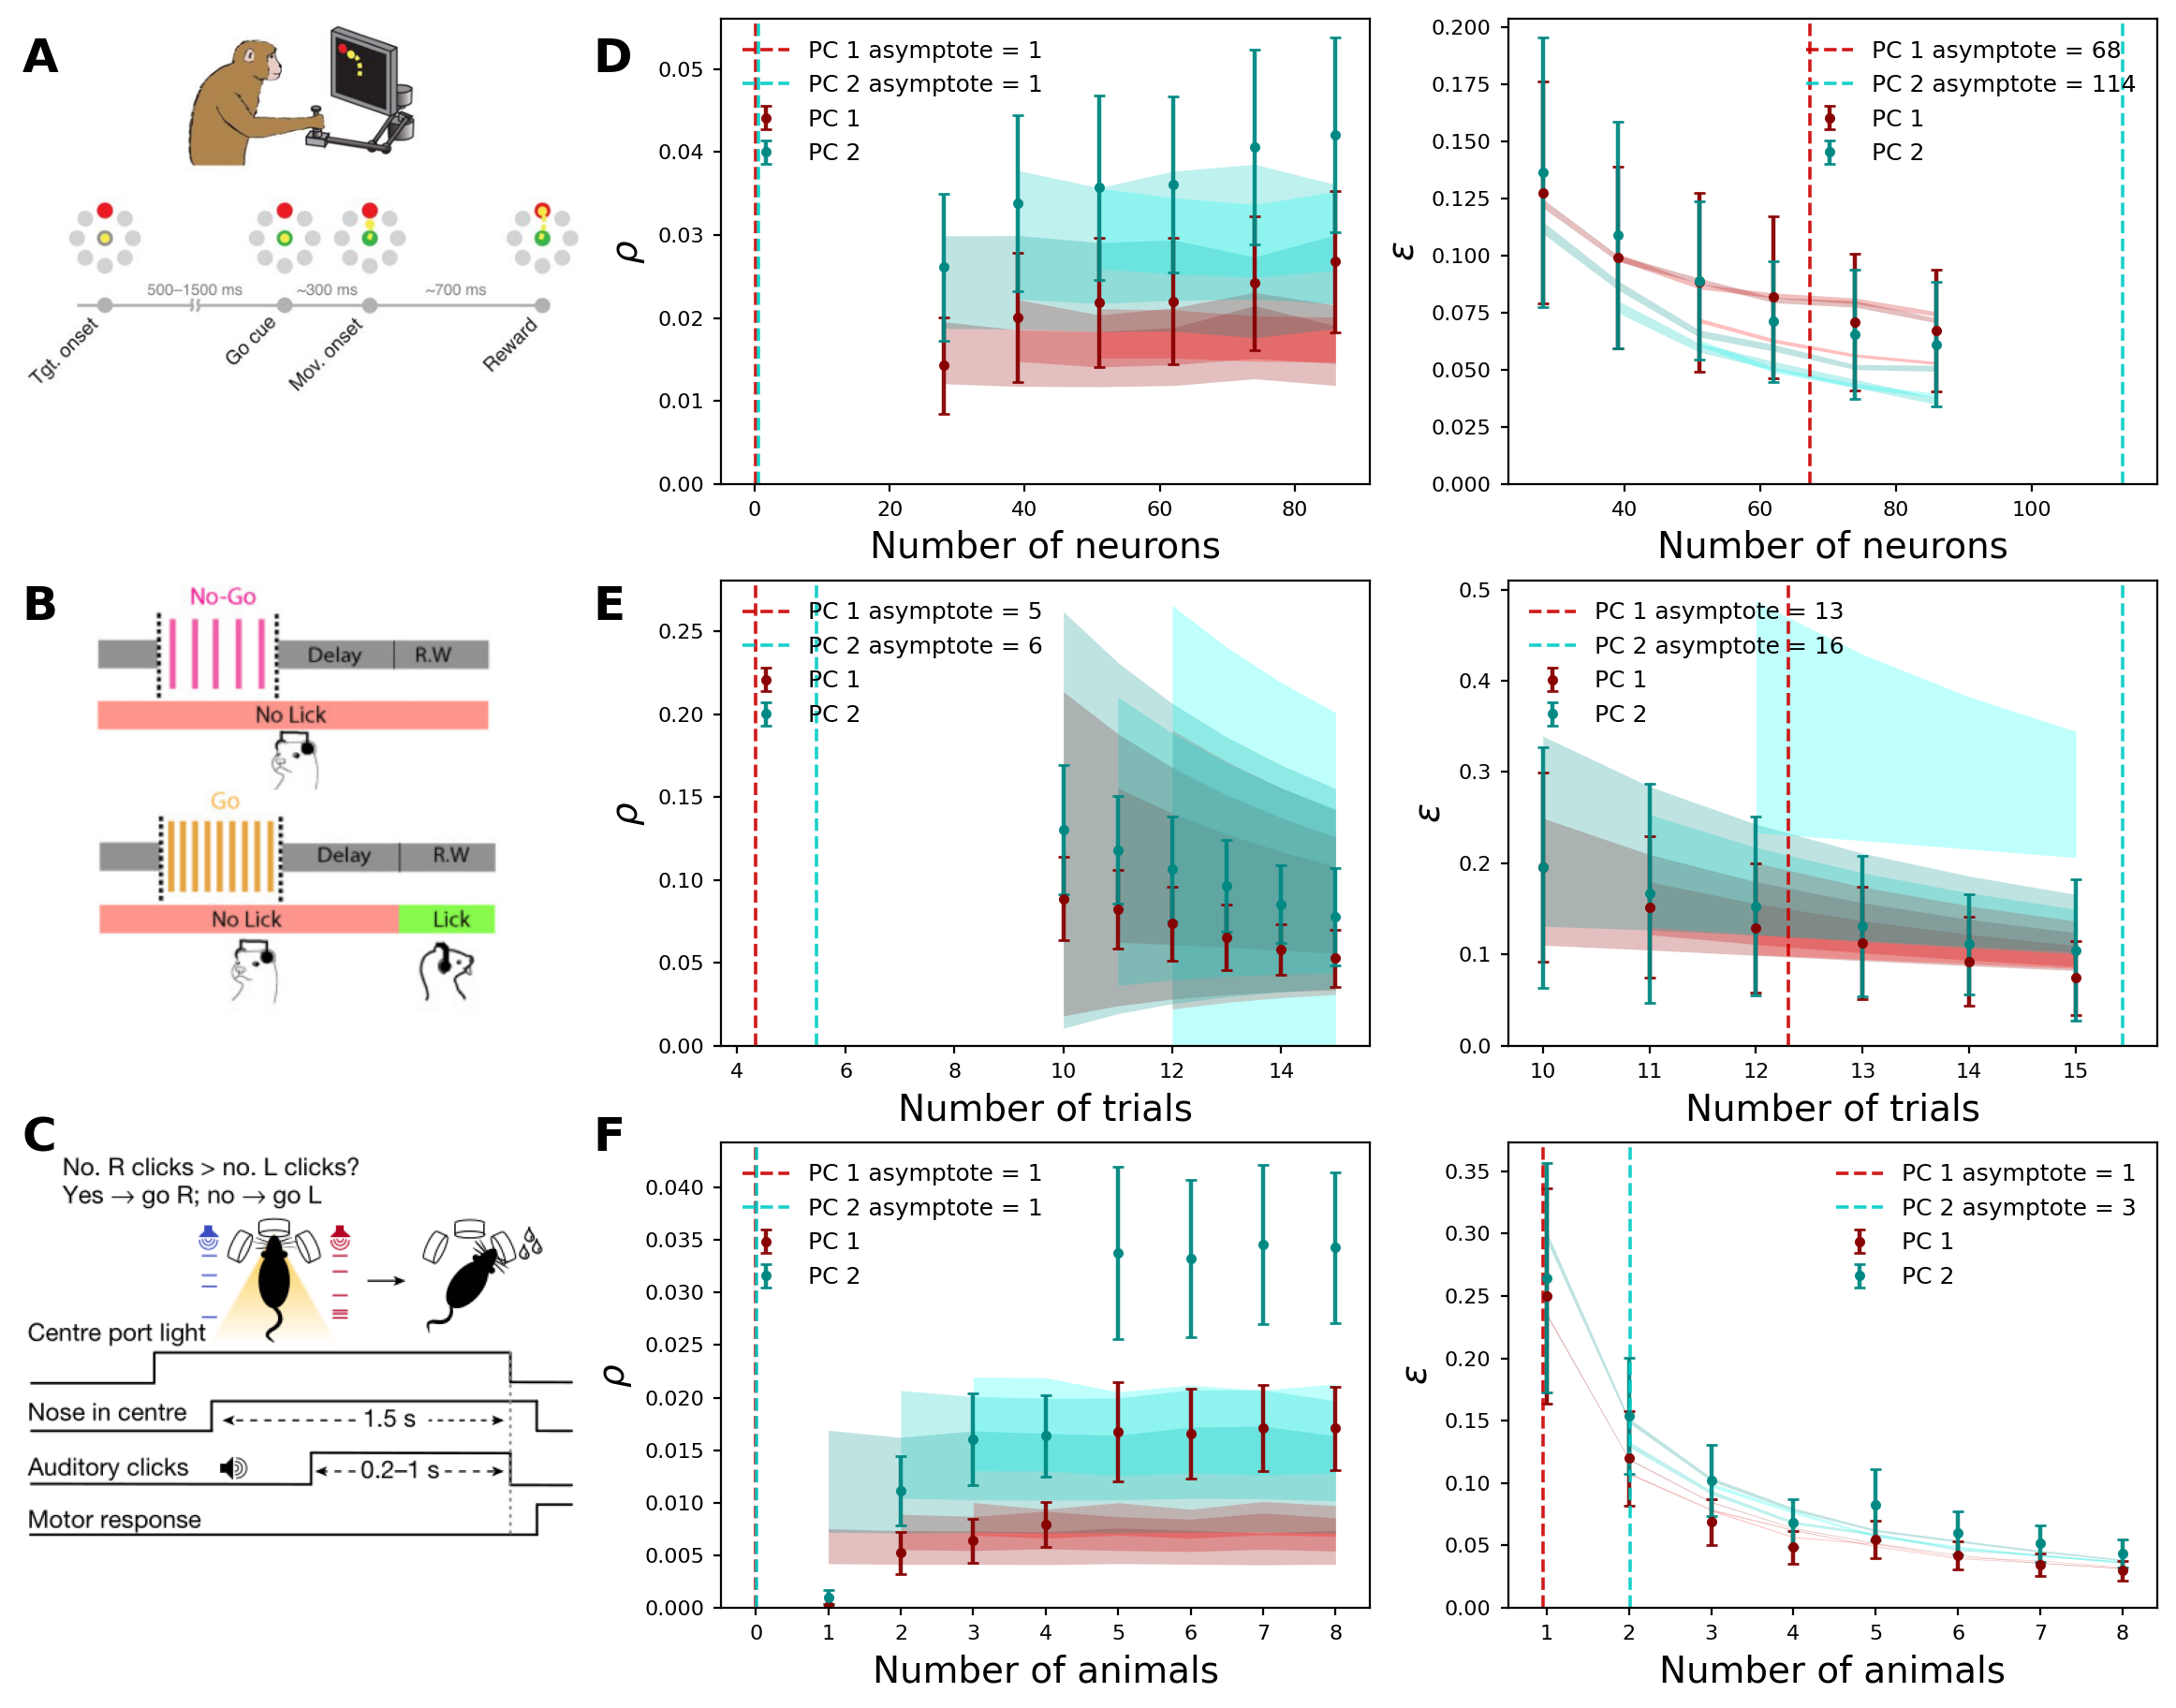

In [9]:
# Plot the full figure again, now adding vertical asymptotic-onset lines.
#
# This cell assumes that the previous asymptotics cell has already been run and
# produced the list `asymptotics`.

ASYMPTOTE_OUTPUT_PNG = OUTPUT_DIR / "fig4_with_asymptotes.png"
ASYMPTOTE_OUTPUT_PDF = OUTPUT_DIR / "fig4_with_asymptotes.pdf"


def get_asymptote_value(
    asymptotics: list[dict],
    *,
    dataset_name: str,
    pc_1based: int,
    metric: str,
) -> float:
    """Return rho or epsilon asymptotic onset for one dataset and PC."""
    key = {
        "rho": "rho_asymptotic_onset",
        "epsilon": "epsilon_asymptotic_onset",
    }[metric]

    matches = [
        row for row in asymptotics
        if row["dataset"] == dataset_name and row["PC"] == pc_1based
    ]

    if len(matches) != 1:
        raise ValueError(
            f"Expected exactly one asymptotic result for "
            f"{dataset_name}, PC {pc_1based}; got {len(matches)}."
        )

    return float(matches[0][key])


def plot_metric_panel_with_asymptotes(
    ax,
    x: np.ndarray,
    pred: np.ndarray,
    pred_std: np.ndarray,
    emp: np.ndarray,
    emp_std: np.ndarray,
    metric_label: str,
    xlabel: str,
    components_1based: list[int],
    dataset_name: str,
    metric: str,
    asymptotics: list[dict],
) -> None:
    """
    Same as plot_metric_panel, but with analytical asymptotic-onset lines.

    Unlike the previous version, this expands the x-range so all asymptotic
    estimates for the plotted PCs are visible.
    """
    K = 2
    comp_idx = component_indices(components_1based, K)
    colors = [plt.cm.hsv(i / max(1, K)) for i in range(K)]

    S_pred = pred.shape[0]
    S_emp = emp.shape[0]
    S_draw = max(S_pred, S_emp)

    x = np.asarray(x, dtype=float)
    asymptote_values = []

    for k in comp_idx:
        base_color = np.array(colors[k][:3])

        # Prediction bands
        for s in range(S_pred):
            shade = 0.35 + 0.65 * (s + 1) / max(1, S_draw)
            color = shade * base_color

            y = pred[s, :, k]
            yerr = pred_std[s, :, k]

            ax.fill_between(
                x,
                y - yerr,
                y + yerr,
                color=color,
                alpha=0.25,
                linewidth=0,
            )

        # Empirical points
        for s in range(S_emp):
            shade = 0.35 + 0.55 * (s + 1) / max(1, S_draw)
            color = shade * base_color

            ax.errorbar(
                x,
                emp[s, :, k],
                emp_std[s, :, k],
                linestyle="",
                marker="o",
                markersize=3,
                capsize=2,
                color=color,
                alpha=0.95,
                label=fr"PC {k + 1}" if s == 0 else None,
            )

        # Analytical asymptotic-onset line
        onset = get_asymptote_value(
            asymptotics,
            dataset_name=dataset_name,
            pc_1based=k + 1,
            metric=metric,
        )

        asymptote_values.append(onset)

        ax.axvline(
            onset,
            color=base_color*0.8,
            linestyle="--",
            linewidth=1.3,
            alpha=0.9,
            label=fr"PC {k + 1} asymptote = {np.ceil(onset):.0f}",
        )

    # Expand x-range to include asymptotes
    x_all = np.array(list(x) + asymptote_values, dtype=float)
    x_min = float(np.nanmin(x_all))
    x_max = float(np.nanmax(x_all))
    x_span = x_max - x_min

    if x_span == 0:
        x_span = 1.0

    pad = 0.06 * x_span
    ax.set_xlim(x_min - pad, x_max + pad)

    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel(metric_label, fontsize=14)
    ax.set_ylim(bottom=0)
    ax.tick_params(length=3)
    ax.legend(frameon=False, loc="best", fontsize=9)

def make_figure_with_asymptotes(
    datasets: list[dict],
    components_1based: list[int],
    asymptotics: list[dict],
) -> plt.Figure:
    """Build the original 3 × 3 figure, with asymptotic-onset lines added."""
    fig, ax = plt.subplots(
        nrows=3,
        ncols=3,
        figsize=(11.5, 9.0),
        constrained_layout=True,
        gridspec_kw={"width_ratios": [1.00, 1.15, 1.15]},
    )

    for row, cfg in enumerate(datasets):
        results = load_axis_results(cfg)

        plot_image_panel(ax[row, 0], results["image_path"])

        plot_metric_panel_with_asymptotes(
            ax[row, 1],
            x=results["grid"],
            pred=results["pred_rho"],
            pred_std=results["pred_rho_std"],
            emp=results["emp_rho"],
            emp_std=results["emp_rho_std"],
            metric_label=r"$\rho$",
            xlabel=results["xlabel"],
            components_1based=components_1based,
            dataset_name=cfg["name"],
            metric="rho",
            asymptotics=asymptotics,
        )

        plot_metric_panel_with_asymptotes(
            ax[row, 2],
            x=results["grid"],
            pred=results["pred_eps"],
            pred_std=results["pred_eps_std"],
            emp=results["emp_eps"],
            emp_std=results["emp_eps_std"],
            metric_label=r"$\epsilon$",
            xlabel=results["xlabel"],
            components_1based=components_1based,
            dataset_name=cfg["name"],
            metric="epsilon",
            asymptotics=asymptotics,
        )

        print(
            f"{cfg['curve_label']}: loaded {cfg['name']} "
            f"from {results['results_dir']} "
            f"using axis_name='{results['axis_name']}'"
        )

    add_panel_labels_absolute(fig)
    return fig


fig = make_figure_with_asymptotes(
    DATASETS,
    components_1based=COMPONENTS_1BASED,
    asymptotics=asymptotics,
)

fig.savefig(ASYMPTOTE_OUTPUT_PNG, bbox_inches="tight")
fig.savefig(ASYMPTOTE_OUTPUT_PDF, bbox_inches="tight")

print(f"Saved PNG: {ASYMPTOTE_OUTPUT_PNG}")
print(f"Saved PDF: {ASYMPTOTE_OUTPUT_PDF}")

plt.show()